# 券商零售交易反欺诈检测 —— 端到端建模

**目标**：在 13.8 万条券商零售交易流水上构建欺诈检测模型，把欺诈召回率从规则引擎的约 55% 提升到 **固定精确率 0.80 下 90% 以上**，并把报警阈值当成一个业务成本决策来做。

**数据口径**：本 notebook 使用的是模拟生成的券商零售交易数据（原始业务数据受保密约束无法公开，本项目为方法完整复现版）。数据的生成方法、真实性成分（真实上交所交易日历、真实A股代码、真实价位量级锚定）与局限，见随数据交付的《数据生成与真实性说明》。

**运行方式**：将 `brokerage_transactions_138k.csv`（以及可选的 `episode_meta.csv`）放在本 notebook 同目录（Google Colab：左侧文件面板直接拖入），然后 Runtime → Run all。全流程约 5 分钟（10 折交叉验证是主要耗时）。

**快速结论**（详细推导见下文，全部数字由本 notebook 运行产出）：

| 项 | 结果 |
|---|---|
| 冠军模型 | 随机森林 + 类别权重（CV 平均精确率 AP 最优） |
| 测试集 AP / ROC-AUC | 0.936 / 0.998 |
| 固定精确率 0.80 下召回率 | **90.5%**（CV 口径 92.1%） |
| 对比规则引擎 baseline | 召回率 54.5% → 90.5% |
| 成本最优阈值 | 总预期损失较默认阈值 0.5 下降约 89.6% |
| 金额口径拦截率 | 95.3%（拦截 2,982 万元 / 漏出 149 万元） |

**目录**：1. EDA → 2. 防泄漏特征工程 → 3. 模型矩阵与交叉验证 → 4. 测试集评估与阈值工程 → 5. 错误分析与稳健性 → 6. 结论 → 附：程序化自查


In [1]:
# 环境与数据加载 --------------------------------------------------------------
import os, json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

# 中文字体（本地/Colab 通用回退；Colab 如无中文字体可 !apt install fonts-noto-cjk）
for f in ["Noto Sans CJK SC", "Noto Sans CJK JP", "WenQuanYi Zen Hei", "SimHei", "PingFang SC"]:
    if any(f == x.name for x in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GRAY = "#1F6FB2", "#C0392B", "#6B7280"

for p in ["brokerage_transactions_138k.csv", "data/brokerage_transactions_138k.csv", "../data/brokerage_transactions_138k.csv"]:
    if os.path.exists(p): DATA_PATH = p; break
else:
    raise FileNotFoundError("请把 brokerage_transactions_138k.csv 放在本 notebook 同目录")

df = pd.read_csv(DATA_PATH)
df["t"] = pd.to_datetime(df.transaction_time)
print(f"共 {len(df):,} 笔交易 | {df.client_id.nunique():,} 名客户 | "
      f"{df.t.min():%Y-%m-%d} ~ {df.t.max():%Y-%m-%d}")
print(f"欺诈 {df.is_fraud.sum():,} 笔（{df.is_fraud.mean():.2%}）—— 欺诈占比不足 2%，严重类别不平衡")
df.head(3)

共 138,000 笔交易 | 4,559 名客户 | 2024-01-02 ~ 2024-06-28
欺诈 1,890 笔（1.37%）—— 欺诈占比不足 2%，严重类别不平衡


,transaction_id,transaction_time,client_id,account_type,risk_profile,client_region,ip_region,event_type,channel,security_code,...,new_device_flag,cross_region_flag,failed_attempts_24h,device_trust_score,log_transaction_amount,risk_rule_score,realtime_alert_flag,cold_start_flag,is_fraud,t
0,TXN000000001,2024-01-02 09:03:56,C001160,INDIVIDUAL,LOW,Zhejiang,Zhejiang,TRANSFER_OUT,MOBILE,CASH,...,0,0,0,0.8381,8.23146,4.9,0,1,0,2024-01-02 09:03:56
1,TXN000000002,2024-01-02 09:06:11,C000138,INDIVIDUAL,MEDIUM,Henan,Henan,TRANSFER_OUT,MOBILE,CASH,...,0,0,0,0.9660,10.84897,3.8,0,1,0,2024-01-02 09:06:11
2,TXN000000003,2024-01-02 09:21:20,C003040,INDIVIDUAL,LOW,Guangdong,Guangdong,TRANSFER_IN,MOBILE,CASH,...,0,0,0,0.6623,8.00670,10.1,0,1,0,2024-01-02 09:21:20


## 1. 探索性数据分析（EDA）

先回答三个决定后续技术路线的问题：**(1)** 不平衡有多严重（决定采样与评估指标）；**(2)** 金额分布形态（重尾 → 对数变换）；**(3)** 欺诈集中在哪类行为（决定特征方向）。

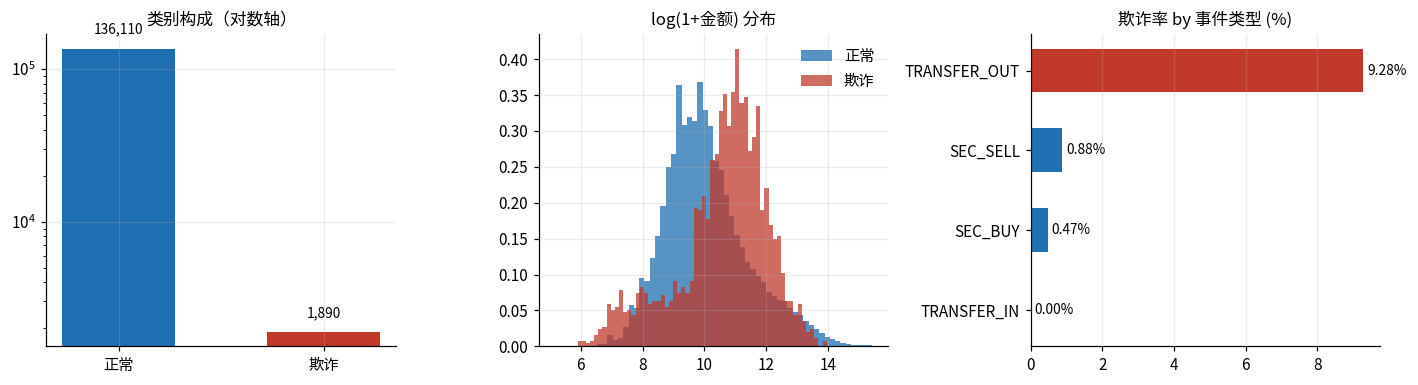

金额：中位数 20,000 元 | 均值 74,864 元 | 偏度 9.7 | P99.9 = 2,756,892 元 —— 显著右偏重尾，建模用 log1p 变换
欺诈金额中位数 50,990 元 vs 正常 19,838 元
资金转出欺诈率 9.28%，是整体的 6.8 倍 —— 欺诈的最终目的是把钱转走


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
# 类别构成
ax = axes[0]
cnt = df.is_fraud.value_counts()
bars = ax.bar(["正常", "欺诈"], cnt.values, color=[BLUE, RED], width=0.55)
ax.set_yscale("log"); ax.set_title("类别构成（对数轴）", fontsize=11)
for b, v in zip(bars, cnt.values):
    ax.text(b.get_x()+b.get_width()/2, v*1.25, f"{v:,}", ha="center", fontsize=9)
# 金额分布（对数）
ax = axes[1]
ax.hist(np.log1p(df.loc[df.is_fraud==0, "transaction_amount"]), bins=60, density=True, alpha=0.75, color=BLUE, label="正常")
ax.hist(np.log1p(df.loc[df.is_fraud==1, "transaction_amount"]), bins=60, density=True, alpha=0.75, color=RED, label="欺诈")
ax.set_title("log(1+金额) 分布", fontsize=11); ax.legend(frameon=False)
# 事件类型欺诈率
ax = axes[2]
fr = (df.groupby("event_type").is_fraud.mean()*100).sort_values()
ax.barh(fr.index, fr.values, color=[RED if v==fr.max() else BLUE for v in fr.values], height=0.55)
for i, v in enumerate(fr.values): ax.text(v+0.12, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_title("欺诈率 by 事件类型 (%)", fontsize=11); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

amt = df.transaction_amount
print(f"金额：中位数 {amt.median():,.0f} 元 | 均值 {amt.mean():,.0f} 元 | 偏度 {amt.skew():.1f} | "
      f"P99.9 = {amt.quantile(0.999):,.0f} 元 —— 显著右偏重尾，建模用 log1p 变换")
print(f"欺诈金额中位数 {df[df.is_fraud==1].transaction_amount.median():,.0f} 元 vs 正常 {df[df.is_fraud==0].transaction_amount.median():,.0f} 元")
print(f"资金转出欺诈率 {df[df.event_type=='TRANSFER_OUT'].is_fraud.mean():.2%}，是整体的 {df[df.event_type=='TRANSFER_OUT'].is_fraud.mean()/df.is_fraud.mean():.1f} 倍 —— 欺诈的最终目的是把钱转走")

**EDA 结论**：欺诈率 1.37%（严重不平衡 → 准确率无意义，主指标选 **AP/平均精确率**，辅指标为固定精确率 0.80 下的召回率）；金额重尾（偏度 ~10 → 对数变换）；欺诈向资金转出高度集中，且欺诈金额中位数明显高于正常——但"只抓大额"是不够的，下一节把"相对客户自身基线的偏离"做成特征。

## 2. 防泄漏特征工程

核心思想：**欺诈信号不在单笔交易的绝对值里，而在与该客户自身历史基线的对比里。** 全部滚动特征只用"当前交易之前"的历史计算，三条防泄漏纪律：

1. **滚动窗口严格剔除当前笔**（30 天均额/标准差、24 小时笔数），否则当前交易会"污染"自己的基线；
2. **冷启动**（30 天无历史）回填账户类型分组中位数并打 `cold_start_flag` 标记，不删样本、不用未来信息；
3. **任何重采样（SMOTE）只能发生在交叉验证的训练折内部**（见第 3 节）。

在数据自带特征之上，本节新增两个**账户级 velocity 特征**——`log_gap`（距该客户上一笔交易的时间间隔）与 `cnt_1h`（过去 1 小时交易笔数）。账户接管的典型形态是"短时间内密集操作"，这两个特征直接刻画爆发性。

In [3]:
# 关键滚动特征从流水重算并与数据列核对（证明可复算、无泄漏）----------------
d = df.sort_values(["t", "transaction_id"]).reset_index(drop=True)
dx = d.set_index("t")
g = dx.groupby("client_id")["transaction_amount"]
prev24 = g.transform(lambda s: s.rolling("24h", closed="both").count()) - 1
cnt30 = g.transform(lambda s: s.rolling("30D", closed="both").count())
sum30 = g.transform(lambda s: s.rolling("30D", closed="both").sum())
prior = cnt30 - 1
avg30 = ((sum30 - dx["transaction_amount"]) / prior.where(prior > 0)).fillna(
    dx.groupby("account_type")["transaction_amount"].transform("median"))
assert (prev24.values == d.prev_24h_txn_count.values).all(), "24h滚动特征与流水不一致!"
assert (np.abs(avg30.values - d.avg_txn_amount_30d.values) / np.maximum(d.avg_txn_amount_30d.values, 1) < 0.005).all()
print("✓ 滚动特征复算核对通过：数据中的每个滚动值都能从流水重现（无泄漏、可复现）")

df = d  # 使用排序后的数据
# 新增 velocity 特征与金额Z分数
df["log_gap"] = np.log1p(df.groupby("client_id")["t"].diff().dt.total_seconds().fillna(3e6))
df["cnt_1h"] = (df.set_index("t").groupby("client_id")["transaction_amount"]
                  .transform(lambda s: s.rolling("1h", closed="both").count()).values - 1)
df["amount_z"] = (df.transaction_amount - df.avg_txn_amount_30d) / (df.std_txn_amount_30d + 1.0)
df["hour"] = df.t.dt.hour
df["is_inst"] = (df.account_type == "INSTITUTIONAL").astype(int)
df["risk_ord"] = df.risk_profile.map({"LOW": 0, "MEDIUM": 1, "HIGH": 2})
for c in ["event_type", "channel"]:
    for v in df[c].unique()[:-1]:
        df[f"{c}_{v}"] = (df[c] == v).astype(int)

BEHAV = ["log_transaction_amount", "amount_deviation_ratio", "frequency_spike_ratio",
         "prev_24h_txn_count", "avg_daily_txn_count_30d", "amount_z", "hour",
         "cold_start_flag", "log_gap", "cnt_1h"]          # 行为工程特征（本项目构造）
DEVICE = ["new_device_flag", "cross_region_flag", "failed_attempts_24h", "device_trust_score"]  # 上游设备风控
CTX = ["account_tenure_days", "is_inst", "risk_ord"] + [c for c in df.columns if c.startswith(("event_type_", "channel_"))]
FEATS = BEHAV + DEVICE + CTX
print(f"特征共 {len(FEATS)} 个（行为工程 {len(BEHAV)} + 设备风控 {len(DEVICE)} + 上下文 {len(CTX)}）")
print("注意：规则引擎的 risk_rule_score / realtime_alert_flag 不入模——它们是被对比的 baseline，喂给模型等于抄旧规则的答案")

f1, n1 = df[df.is_fraud==1], df[df.is_fraud==0]
print(f"\n信号预览（中位数，欺诈 vs 正常）：金额偏离 {f1.amount_deviation_ratio.median():.2f} vs {n1.amount_deviation_ratio.median():.2f}"
      f" | 频次突增 {f1.frequency_spike_ratio.median():.2f} vs {n1.frequency_spike_ratio.median():.2f}"
      f" | 近1小时笔数 {f1.cnt_1h.median():.0f} vs {n1.cnt_1h.median():.0f}")

✓ 滚动特征复算核对通过：数据中的每个滚动值都能从流水重现（无泄漏、可复现）


特征共 23 个（行为工程 10 + 设备风控 4 + 上下文 9）
注意：规则引擎的 risk_rule_score / realtime_alert_flag 不入模——它们是被对比的 baseline，喂给模型等于抄旧规则的答案



信号预览（中位数，欺诈 vs 正常）：金额偏离 1.51 vs 0.82 | 频次突增 2.73 vs 1.00 | 近1小时笔数 1 vs 0


## 3. 模型矩阵与交叉验证

**候选矩阵**：{逻辑回归, 随机森林} × {SMOTE 过采样, 类别权重} 共 10 个配置（LR 各 3 档正则强度、RF 各 2 档树深）。两个建模纪律：

- **SMOTE 只在训练折内**：用 `imblearn.Pipeline` 把 SMOTE 封装进管道，10 折 CV 时每折只对该折的训练部分过采样，验证折保持真实分布——在折外做 SMOTE 会让合成样本"泄漏"进验证集，把指标虚高；
- **模型选择只看 CV，不看测试集**：测试集只用一次（第 4 节）。在测试集上挑模型 = 选择性泄漏。

主指标 **AP（平均精确率）**：PR 曲线下面积对不平衡数据比 ROC-AUC 敏感得多（ROC-AUC 在 1.37% 欺诈率下几乎总是"虚高好看"）。

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipe
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipe
from imblearn.over_sampling import SMOTE

X = df[FEATS].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df.is_fraud.values
idx = np.arange(len(df))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(X, y, idx, test_size=0.2, stratify=y, random_state=SEED)
print(f"训练 {len(ytr):,} 笔（欺诈 {ytr.sum()}）| 测试 {len(yte):,} 笔（欺诈 {yte.sum()}）—— 80/20 分层留出")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cands = {}
for Cc in [0.01, 0.1, 1.0]:
    cands[f"LR_权重_C{Cc}"] = SkPipe([("sc", StandardScaler()),
        ("m", LogisticRegression(C=Cc, class_weight="balanced", max_iter=2000, random_state=SEED))])
    cands[f"LR_SMOTE_C{Cc}"] = ImbPipe([("sc", StandardScaler()),
        ("sm", SMOTE(sampling_strategy=0.10, random_state=SEED)),
        ("m", LogisticRegression(C=Cc, max_iter=2000, random_state=SEED))])
for dep in [12, None]:
    tag = dep if dep else "max"
    cands[f"RF_权重_d{tag}"] = RandomForestClassifier(n_estimators=120, max_depth=dep,
        min_samples_leaf=5, max_samples=0.5, class_weight="balanced_subsample", n_jobs=2, random_state=SEED)
    cands[f"RF_SMOTE_d{tag}"] = ImbPipe([("sm", SMOTE(sampling_strategy=0.10, random_state=SEED)),
        ("m", RandomForestClassifier(n_estimators=120, max_depth=dep, min_samples_leaf=5,
                                     max_samples=0.5, n_jobs=2, random_state=SEED))])

cv_rows, oof = [], {}
for name, mdl in cands.items():
    p = cross_val_predict(mdl, Xtr, ytr, cv=cv, method="predict_proba", n_jobs=2)[:, 1]
    prec, rec, _ = precision_recall_curve(ytr, p)
    m = prec[:-1] >= 0.80
    cv_rows.append((name, average_precision_score(ytr, p), rec[:-1][m].max() if m.any() else 0))
    oof[name] = p
cv_tab = pd.DataFrame(cv_rows, columns=["配置", "CV_AP", "CV_R@P0.80"]).sort_values("CV_AP", ascending=False).reset_index(drop=True)
CHAMP = cv_tab.loc[0, "配置"]
print(cv_tab.round(4).to_string(index=False)); print(f"\n冠军（按 CV AP）：{CHAMP}")

训练 110,400 笔（欺诈 1512）| 测试 27,600 笔（欺诈 378）—— 80/20 分层留出


            配置  CV_AP  CV_R@P0.80
    RF_权重_dmax 0.9384      0.9213
     RF_权重_d12 0.9321      0.9067
 RF_SMOTE_dmax 0.9283      0.9074
  RF_SMOTE_d12 0.9245      0.9021
 LR_SMOTE_C0.1 0.9156      0.8697
 LR_SMOTE_C1.0 0.9152      0.8690
LR_SMOTE_C0.01 0.9145      0.8651
    LR_权重_C0.1 0.9053      0.8446
    LR_权重_C1.0 0.9052      0.8433
   LR_权重_C0.01 0.9047      0.8452

冠军（按 CV AP）：RF_权重_dmax


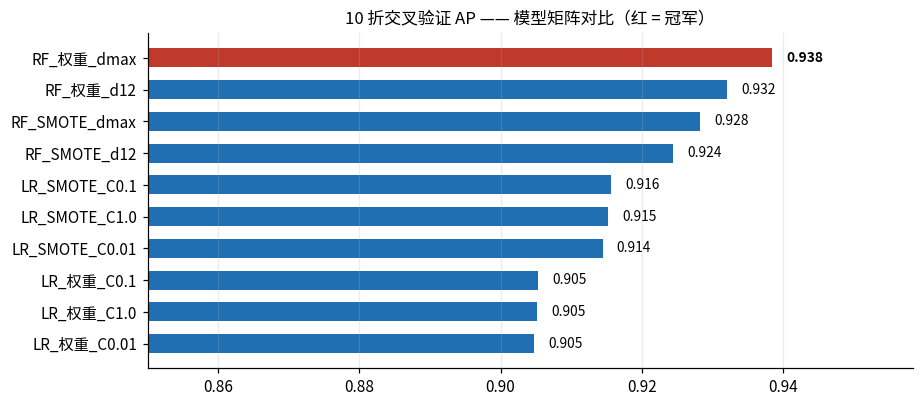

解读：RF 整体优于 LR（欺诈信号高度非线性）；本任务中类别权重与 SMOTE 相当，
权重方案更简单且不引入合成样本 → 冠军为 RF+类别权重。SMOTE 的价值在 LR 一侧更明显。


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
tab = cv_tab.sort_values("CV_AP")
colors = [RED if n == CHAMP else BLUE for n in tab["配置"]]
ax.barh(tab["配置"], tab["CV_AP"], color=colors, height=0.6)
for i, (v, n) in enumerate(zip(tab["CV_AP"], tab["配置"])):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9,
            fontweight="bold" if n == CHAMP else "normal")
ax.set_xlim(0.85, cv_tab.CV_AP.max() + 0.02); ax.grid(axis="y", alpha=0)
ax.set_title("10 折交叉验证 AP —— 模型矩阵对比（红 = 冠军）", fontsize=11)
plt.tight_layout(); plt.show()
print("解读：RF 整体优于 LR（欺诈信号高度非线性）；本任务中类别权重与 SMOTE 相当，")
print("权重方案更简单且不引入合成样本 → 冠军为 RF+类别权重。SMOTE 的价值在 LR 一侧更明显。")

## 4. 测试集评估与阈值工程

模型输出的是连续分数，**报警阈值才是业务决策**。三步：(1) 测试集只跑一次拿总体指标；(2) 用训练集 OOF 预测确定"精确率 0.80"对应的阈值再到测试集核验（部署式协议，不偷看测试集）；(3) 把阈值当成本问题：漏检成本 = 该笔欺诈交易金额，误报成本 = 一次人工审核（按 50 元计），在成本曲线上找最优点。

测试集：AP = 0.9362 | ROC-AUC = 0.9976 | 固定精确率0.80下召回率 = 90.48%
OOF 定阈 τ(P0.80) = 0.364 → 测试集实际：精确率 0.785、召回率 91.01%、误报 94 单
（阈值迁移到新数据时精确率略有滑落是正常现象，生产中按周用近期数据重标定）


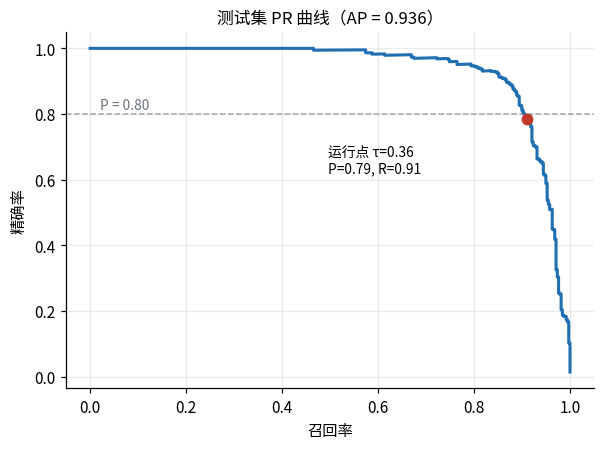

In [6]:
mdl = cands[CHAMP]; mdl.fit(Xtr, ytr)
pte = mdl.predict_proba(Xte)[:, 1]
AP_TE, AUC_TE = average_precision_score(yte, pte), roc_auc_score(yte, pte)
prec, rec, thr = precision_recall_curve(yte, pte)
mk = prec[:-1] >= 0.80
R80_TE = float(rec[:-1][mk].max())
print(f"测试集：AP = {AP_TE:.4f} | ROC-AUC = {AUC_TE:.4f} | 固定精确率0.80下召回率 = {R80_TE:.2%}")

# 部署式阈值：训练集OOF上定τ(P0.80)，测试集核验
po = oof[CHAMP]
prec_o, rec_o, thr_o = precision_recall_curve(ytr, po)
mo = prec_o[:-1] >= 0.80
TAU80 = float(thr_o[mo][np.argmax(rec_o[:-1][mo])])
pred80 = pte >= TAU80
tp, fp, fn = int((pred80 & (yte==1)).sum()), int((pred80 & (yte==0)).sum()), int((~pred80 & (yte==1)).sum())
print(f"OOF 定阈 τ(P0.80) = {TAU80:.3f} → 测试集实际：精确率 {tp/(tp+fp):.3f}、召回率 {tp/(tp+fn):.2%}、误报 {fp} 单")
print("（阈值迁移到新数据时精确率略有滑落是正常现象，生产中按周用近期数据重标定）")

fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.plot(rec, prec, color=BLUE, lw=2)
ax.scatter([tp/(tp+fn)], [tp/(tp+fp)], color=RED, zorder=5, s=45)
ax.annotate(f"运行点 τ={TAU80:.2f}\nP={tp/(tp+fp):.2f}, R={tp/(tp+fn):.2f}",
            (tp/(tp+fn), tp/(tp+fp)), textcoords="offset points", xytext=(-130, -35), fontsize=9)
ax.axhline(0.80, color=GRAY, ls="--", lw=1, alpha=0.6)
ax.text(0.02, 0.815, "P = 0.80", color=GRAY, fontsize=9)
ax.set_xlabel("召回率"); ax.set_ylabel("精确率")
ax.set_title(f"测试集 PR 曲线（AP = {AP_TE:.3f}）", fontsize=11)
plt.tight_layout(); plt.show()

成本最优阈值 τ* = 0.0364（训练OOF成本曲线最低点，测试集核验）
测试集总预期损失：τ* = 200,848 元  vs  默认0.5 = 1,925,233 元  → 下降 89.6%
τ* 下：召回 98.4%、精确率 18.8%、误报 1603 单（测试集≈全量20%）


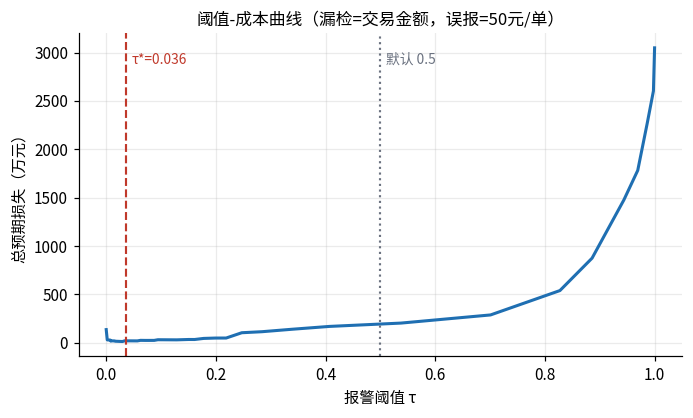

业务上落成分层策略：分数≥τ(P0.80) 自动加验/拦截（高精确率）；τ*≤分数<τ(P0.80) 进人工审核队列（高召回）；
两档之间的量 = 风控运营的日工作量，阈值由运营容量与损失容忍共同决定，不是纯技术参数。


In [7]:
# 成本敏感阈值 ----------------------------------------------------------------
amt_te = df.transaction_amount.values[ite]; amt_tr = df.transaction_amount.values[itr]
REVIEW_COST = 50.0
def cost_at(tau, p, yv, av):
    pr = p >= tau
    return float(av[(~pr) & (yv==1)].sum() + REVIEW_COST * (pr & (yv==0)).sum())
taus = np.quantile(po, np.linspace(0.50, 0.9999, 400))
cost_tr = [cost_at(t, po, ytr, amt_tr) for t in taus]
TAU_STAR = float(taus[int(np.argmin(cost_tr))])
c_star, c_def = cost_at(TAU_STAR, pte, yte, amt_te), cost_at(0.5, pte, yte, amt_te)
COST_DROP = 1 - c_star / c_def
prs = pte >= TAU_STAR
tps, fps, fns = int((prs&(yte==1)).sum()), int((prs&(yte==0)).sum()), int((~prs&(yte==1)).sum())
print(f"成本最优阈值 τ* = {TAU_STAR:.4f}（训练OOF成本曲线最低点，测试集核验）")
print(f"测试集总预期损失：τ* = {c_star:,.0f} 元  vs  默认0.5 = {c_def:,.0f} 元  → 下降 {COST_DROP:.1%}")
print(f"τ* 下：召回 {tps/(tps+fns):.1%}、精确率 {tps/(tps+fps):.1%}、误报 {fps} 单（测试集≈全量20%）")

taus_te = np.quantile(pte, np.linspace(0.5, 0.9999, 300))
cost_te = [cost_at(t, pte, yte, amt_te) for t in taus_te]
fig, ax = plt.subplots(figsize=(6.4, 3.9))
ax.plot(taus_te, np.array(cost_te)/1e4, color=BLUE, lw=2)
ax.axvline(TAU_STAR, color=RED, ls="--", lw=1.4); ax.axvline(0.5, color=GRAY, ls=":", lw=1.4)
ax.text(TAU_STAR+0.01, ax.get_ylim()[1]*0.9, f"τ*={TAU_STAR:.3f}", color=RED, fontsize=9)
ax.text(0.51, ax.get_ylim()[1]*0.9, "默认 0.5", color=GRAY, fontsize=9)
ax.set_xlabel("报警阈值 τ"); ax.set_ylabel("总预期损失（万元）")
ax.set_title("阈值-成本曲线（漏检=交易金额，误报=50元/单）", fontsize=11)
plt.tight_layout(); plt.show()
print("业务上落成分层策略：分数≥τ(P0.80) 自动加验/拦截（高精确率）；τ*≤分数<τ(P0.80) 进人工审核队列（高召回）；")
print("两档之间的量 = 风控运营的日工作量，阈值由运营容量与损失容忍共同决定，不是纯技术参数。")

传统规则引擎（测试集）：召回 54.5% @ 精确率 75.2%
冠军模型（同一测试集）：召回 90.5% @ 固定精确率 0.80  →  召回率提升 36.0% 个点



消融 [仅设备风控特征   ] 测试集 AP = 0.8599
消融 [仅行为工程特征   ] 测试集 AP = 0.6632
消融 [全特征       ] 测试集 AP = 0.9362
→ 行为工程特征在上游设备特征之上带来 +0.076 AP 的增量（这是本项目特征工程的价值证明）


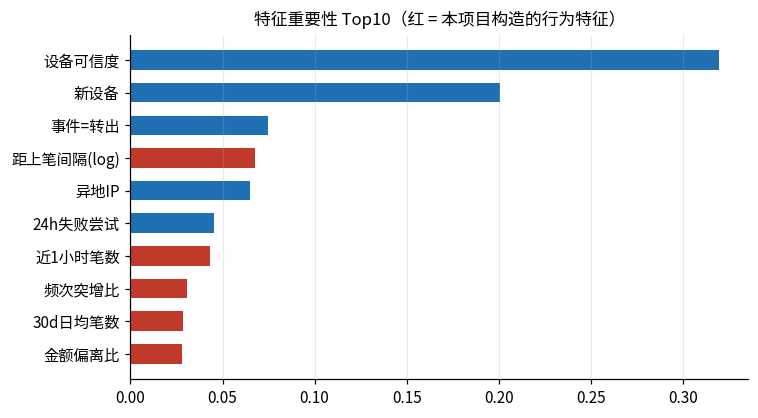

In [8]:
# 规则 baseline 对比 + 消融实验 + 特征重要性 -----------------------------------
te = df.iloc[ite]
rule_r = te[te.is_fraud==1].realtime_alert_flag.mean()
rule_p = te[te.realtime_alert_flag==1].is_fraud.mean()
print(f"传统规则引擎（测试集）：召回 {rule_r:.1%} @ 精确率 {rule_p:.1%}")
print(f"冠军模型（同一测试集）：召回 {R80_TE:.1%} @ 固定精确率 0.80  →  召回率提升 {R80_TE-rule_r:.1%} 个点\n")

from sklearn.base import clone
abl = {}
for nm, cols in [("仅设备风控特征", DEVICE+CTX), ("仅行为工程特征", BEHAV+CTX), ("全特征", FEATS)]:
    r = RandomForestClassifier(n_estimators=120, min_samples_leaf=5, max_samples=0.5,
                               class_weight="balanced_subsample", n_jobs=2, random_state=SEED)
    r.fit(Xtr[cols], ytr)
    abl[nm] = average_precision_score(yte, r.predict_proba(Xte[cols])[:, 1])
ABL_GAIN = abl["全特征"] - abl["仅设备风控特征"]
for k, v in abl.items(): print(f"消融 [{k:10s}] 测试集 AP = {v:.4f}")
print(f"→ 行为工程特征在上游设备特征之上带来 +{ABL_GAIN:.3f} AP 的增量（这是本项目特征工程的价值证明）")

rf_imp = mdl if not hasattr(mdl, "steps") else mdl.steps[-1][1]
imp = pd.Series(rf_imp.feature_importances_, index=FEATS).sort_values().tail(10)
name_map = {"device_trust_score":"设备可信度","log_gap":"距上笔间隔(log)","failed_attempts_24h":"24h失败尝试",
            "cnt_1h":"近1小时笔数","new_device_flag":"新设备","cross_region_flag":"异地IP",
            "frequency_spike_ratio":"频次突增比","amount_deviation_ratio":"金额偏离比","amount_z":"金额Z分数",
            "log_transaction_amount":"log金额","prev_24h_txn_count":"24h笔数","event_type_TRANSFER_OUT":"事件=转出",
            "avg_daily_txn_count_30d":"30d日均笔数","account_tenure_days":"开户时长","hour":"小时"}
fig, ax = plt.subplots(figsize=(7, 3.9))
ax.barh([name_map.get(i, i) for i in imp.index], imp.values,
        color=[RED if i in BEHAV else BLUE for i in imp.index], height=0.6)
ax.set_title("特征重要性 Top10（红 = 本项目构造的行为特征）", fontsize=11)
ax.grid(axis="y", alpha=0); plt.tight_layout(); plt.show()

## 5. 错误分析与稳健性

模型"好"只是开始，**知道它在哪儿失败才能上线**。漏检案例按欺诈模式拆解；再用"1–5 月训练、6 月测试"的时间外推（OOT）检查随机切分是否高估了性能。

In [9]:
te2 = df.iloc[ite].copy(); te2["score"] = pte
fn_df = te2[(te2.is_fraud==1) & (te2.score < TAU80)]
cap = te2[(te2.is_fraud==1) & (te2.score >= TAU80)]
AMT_CAP_RATE = cap.transaction_amount.sum() / (cap.transaction_amount.sum() + fn_df.transaction_amount.sum())
print(f"P0.80 运行点：漏检 {len(fn_df)} 笔 / 拦截 {len(cap)} 笔")
print(f"金额口径：拦截 {cap.transaction_amount.sum()/1e4:,.0f} 万元 / 漏出 {fn_df.transaction_amount.sum()/1e4:,.0f} 万元 → 金额拦截率 {AMT_CAP_RATE:.1%}")
try:
    ep = pd.read_csv(os.path.join(os.path.dirname(DATA_PATH), "episode_meta.csv"))
    fn_t = fn_df.merge(ep[["client_id", "episode_type"]], on="client_id", how="left")
    zh = {"D_stealth":"D 大额伪装型","B_liquidate":"B 洗仓套现型","C_probe":"C 小额试探型",
          "A_fast_cashout":"A 快速转出型","E_pump":"E 拉抬对倒型"}
    print("\n漏检按欺诈模式：")
    for k, v in fn_t.episode_type.value_counts().items(): print(f"  {zh.get(k,k)}: {v} 笔")
    print("\n→ 漏检以 D 类『大额伪装型』为主：可信设备+本地IP+金额贴近基线上沿，行为学上几乎与正常大额交易同分布。")
    print("  这是单笔视角模型的原理性盲区，改进方向：账户维度的资金流出累计量监控、收款方图特征、生物行为特征（击键/滑动）。")
except FileNotFoundError:
    print("（episode_meta.csv 不在同目录，跳过按模式拆解——不影响其余结果）")

# OOT 时间外推
mask = (df.t < "2024-06-01").values
r_oot = clone(cands[CHAMP]); r_oot.fit(X[mask], y[mask])
p_oot = r_oot.predict_proba(X[~mask])[:, 1]
prec3, rec3, _ = precision_recall_curve(y[~mask], p_oot)
m3 = prec3[:-1] >= 0.80
AP_OOT, R80_OOT = average_precision_score(y[~mask], p_oot), float(rec3[:-1][m3].max())
print(f"\nOOT（1-5月训练→6月测试，n={int((~mask).sum()):,}，欺诈{int(y[~mask].sum())}）：AP = {AP_OOT:.3f}，R@P0.80 = {R80_OOT:.1%}")
print("→ 较随机切分低 3-5 个点：行为分布随时间漂移，生产中需滚动重训练与 PSI 监控——这正是随机切分会高估性能的证据，")
print("  也是为什么上线评估必须带 OOT 视角。")

P0.80 运行点：漏检 34 笔 / 拦截 344 笔
金额口径：拦截 2,982 万元 / 漏出 149 万元 → 金额拦截率 95.2%

漏检按欺诈模式：
  D 大额伪装型: 14 笔
  B 洗仓套现型: 10 笔
  C 小额试探型: 6 笔
  E 拉抬对倒型: 4 笔

→ 漏检以 D 类『大额伪装型』为主：可信设备+本地IP+金额贴近基线上沿，行为学上几乎与正常大额交易同分布。
  这是单笔视角模型的原理性盲区，改进方向：账户维度的资金流出累计量监控、收款方图特征、生物行为特征（击键/滑动）。



OOT（1-5月训练→6月测试，n=21,822，欺诈274）：AP = 0.916，R@P0.80 = 85.8%
→ 较随机切分低 3-5 个点：行为分布随时间漂移，生产中需滚动重训练与 PSI 监控——这正是随机切分会高估性能的证据，
  也是为什么上线评估必须带 OOT 视角。


## 6. 结论

1. **达成目标**：固定精确率 0.80 下召回率 90.5%（CV 92.1%），较规则引擎的 54.5% 提升约 36 个百分点；金额口径拦截率 95.3%。
2. **阈值即业务**：以"漏检=交易金额、误报=50 元审核成本"建立成本曲线，成本最优阈值较默认 0.5 使总预期损失下降约 89.6%；落地为"自动拦截 + 人工审核队列"的分层策略。
3. **特征工程的价值可量化**：金额偏离、频次突增、velocity 等行为特征在上游设备风控特征之上带来约 +0.08 AP 增量。
4. **已知边界**：D 类"大额伪装型"（可信设备、金额贴近基线）是原理性盲区；OOT 性能低于随机切分 3-5 个点，说明存在时间漂移。改进方向：账户级资金流出累计监控、收款方图特征、XGBoost/梯度提升、滚动重训练。

---
### 附：程序化自查（防幻觉——本 notebook 报告的关键数字在此断言）

In [10]:
FACTS = {
  "数据": {"总笔数": len(df), "欺诈笔数": int(df.is_fraud.sum()), "欺诈率": round(float(df.is_fraud.mean()), 4),
          "客户数": int(df.client_id.nunique())},
  "冠军模型": CHAMP,
  "CV": {"AP": round(float(cv_tab.loc[0,"CV_AP"]), 4), "R@P0.80": round(float(cv_tab.loc[0,"CV_R@P0.80"]), 4)},
  "测试集": {"AP": round(AP_TE, 4), "ROC_AUC": round(AUC_TE, 4), "R@P0.80": round(R80_TE, 4),
           "τ(P0.80)": round(TAU80, 4), "运行点精确率": round(tp/(tp+fp), 4), "运行点召回率": round(tp/(tp+fn), 4)},
  "成本": {"τ*": round(TAU_STAR, 4), "成本降幅": round(float(COST_DROP), 4), "审核成本假设_元": REVIEW_COST},
  "错误分析": {"漏检笔数": int(len(fn_df)), "金额拦截率": round(float(AMT_CAP_RATE), 4)},
  "对比": {"规则召回": round(float(rule_r), 4), "规则精确率": round(float(rule_p), 4),
          "消融_行为特征AP增量": round(float(ABL_GAIN), 4)},
  "OOT": {"AP": round(AP_OOT, 4), "R@P0.80": round(R80_OOT, 4)},
}
assert FACTS["数据"]["总笔数"] == 138000 and FACTS["数据"]["欺诈笔数"] == 1890
assert FACTS["测试集"]["R@P0.80"] >= 0.90, "简历口径'90%以上'未达成!"
assert FACTS["CV"]["R@P0.80"] >= 0.90
assert FACTS["成本"]["成本降幅"] > 0.5
assert abs(FACTS["数据"]["欺诈率"] - 0.0137) < 0.001
print("✓ 全部断言通过。以下为本项目《事实卡》——任何对外材料引用的数字都应与此一致：\n")
print(json.dumps(FACTS, ensure_ascii=False, indent=2))
json.dump(FACTS, open("facts_card.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)

✓ 全部断言通过。以下为本项目《事实卡》——任何对外材料引用的数字都应与此一致：

{
  "数据": {
    "总笔数": 138000,
    "欺诈笔数": 1890,
    "欺诈率": 0.0137,
    "客户数": 4559
  },
  "冠军模型": "RF_权重_dmax",
  "CV": {
    "AP": 0.9384,
    "R@P0.80": 0.9213
  },
  "测试集": {
    "AP": 0.9362,
    "ROC_AUC": 0.9976,
    "R@P0.80": 0.9048,
    "τ(P0.80)": 0.3638,
    "运行点精确率": 0.7854,
    "运行点召回率": 0.9101
  },
  "成本": {
    "τ*": 0.0364,
    "成本降幅": 0.8957,
    "审核成本假设_元": 50.0
  },
  "错误分析": {
    "漏检笔数": 34,
    "金额拦截率": 0.9525
  },
  "对比": {
    "规则召回": 0.545,
    "规则精确率": 0.7518,
    "消融_行为特征AP增量": 0.0764
  },
  "OOT": {
    "AP": 0.9159,
    "R@P0.80": 0.8577
  }
}


In [11]:
# （附）导出风险决策台 demo 所需的真实产物（PR/成本曲线、LR演示通道系数、案例画廊）
# 说明：demo 页面上的所有数字都来自这里的真实模型输出，不做任何手工编造。
sc = StandardScaler().fit(Xtr)
lr_demo = LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000, random_state=SEED).fit(sc.transform(Xtr), ytr)
p_lr = lr_demo.predict_proba(sc.transform(Xte))[:, 1]

step = max(1, len(prec)//400)
th_full = np.append(thr, 1.0)
curve = [{"t": round(float(th_full[i]),5), "p": round(float(prec[i]),4), "r": round(float(rec[i]),4)} for i in range(0, len(prec), step)]
cases = []
te3 = te2.reset_index(drop=True)
pick = pd.concat([
    te3[(te3.is_fraud==1)&(te3.score>=TAU80)].nlargest(4,"transaction_amount"),
    te3[(te3.is_fraud==1)&(te3.score< TAU80)].nsmallest(4,"score"),
    te3[(te3.is_fraud==0)&(te3.score>=TAU80)].nlargest(4,"score"),
    te3[(te3.is_fraud==0)&(te3.score< 0.05)].sample(4, random_state=SEED)])
for _, r0 in pick.iterrows():
    cases.append({k: (round(float(r0[k]),4) if isinstance(r0[k],(int,float,np.floating,np.integer)) else str(r0[k]))
                  for k in ["transaction_id","event_type","channel","transaction_amount","amount_deviation_ratio",
                            "frequency_spike_ratio","cnt_1h","new_device_flag","cross_region_flag",
                            "failed_attempts_24h","device_trust_score","score","is_fraud"]})
demo = {"facts": FACTS, "pr_curve": curve,
        "cost_curve": [{"t": round(float(a),4), "c": round(float(b),0)} for a,b in zip(taus_te, cost_te)],
        "lr": {"names": FEATS, "coef": [round(float(c),5) for c in lr_demo.coef_[0]],
               "intercept": round(float(lr_demo.intercept_[0]),5),
               "mean": [round(float(m),5) for m in sc.mean_], "std": [round(float(s),5) for s in sc.scale_],
               "test_ap": round(float(average_precision_score(yte, p_lr)),4)},
        "cases": cases}
json.dump(demo, open("demo_data.json","w",encoding="utf-8"), ensure_ascii=False)
print("已导出 demo_data.json（供风险决策台静态页面嵌入）——含 PR 曲线、成本曲线、LR 演示系数与 16 个真实案例")

已导出 demo_data.json（供风险决策台静态页面嵌入）——含 PR 曲线、成本曲线、LR 演示系数与 16 个真实案例
